# Health analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Läser in data
df = pd.read_csv("../data/health_study_dataset.csv")

# Kolumner att analysera
columns = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']

rows = []

# Loopar över kolumner
for col in columns:
    col_data = df[col].dropna()
    rows.append({
        'Kolumn': col,
        'Medel': round(col_data.mean(), 2),
        'Median': round(col_data.median(), 2),
        'Min': round(col_data.min(), 2),
        'Max': round(col_data.max(), 2)
    })
# Skapar DataFrame med resultat
stats_df = pd.DataFrame(rows)
stats_df



,Kolumn,Medel,Median,Min,Max
0,age,49.43,50.00,18.0,90.00
1,weight,73.41,73.20,33.7,114.40
2,height,171.85,171.35,144.4,200.40
3,systolic_bp,149.18,149.40,106.8,185.90
4,cholesterol,4.93,4.97,2.5,7.88


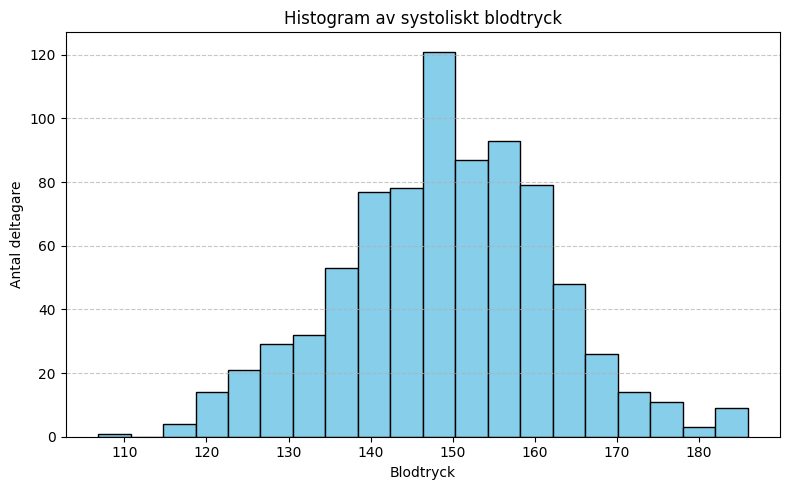

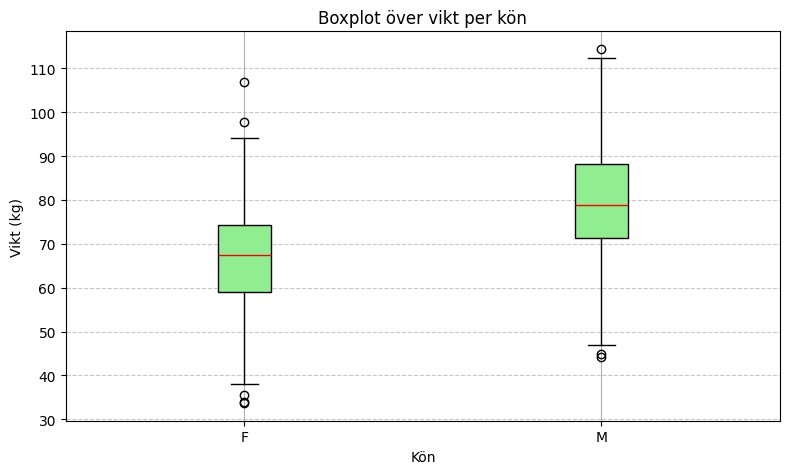

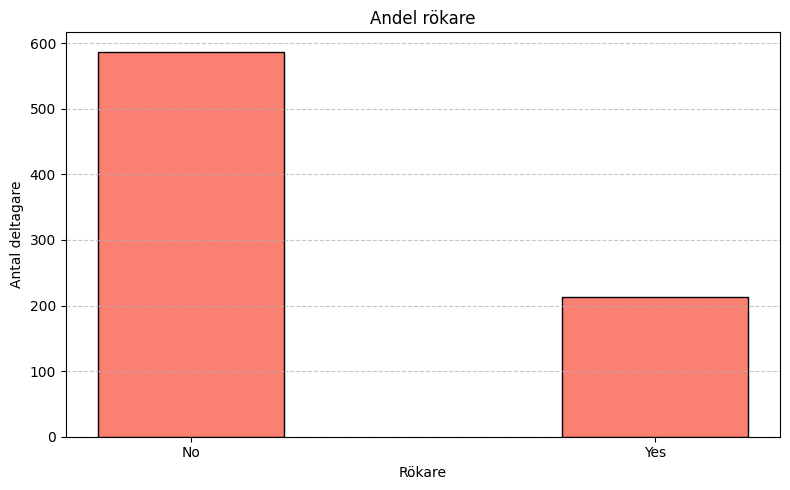

In [2]:


# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['systolic_bp'].dropna(), bins=20, color='skyblue', edgecolor='black')
ax.set_title("Histogram av systoliskt blodtryck")
ax.set_xlabel("Blodtryck")
ax.set_ylabel("Antal deltagare")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
df_box = df[['weight', 'sex']].dropna()
df_box.boxplot(column= 'weight', by='sex', ax=ax, patch_artist=True, 
               boxprops=dict(facecolor='lightgreen', color='black'),
               medianprops=dict(color='red'),  
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))
ax.set_title("Boxplot över vikt per kön")
ax.set_xlabel("Kön")
ax.set_ylabel("Vikt (kg)")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.suptitle("")
plt.tight_layout()
plt.show()

# Bar
fig, ax = plt.subplots(figsize=(8, 5))
smoker_counts = df['smoker'].value_counts()
ax.bar(smoker_counts.index, smoker_counts.values, color='salmon', edgecolor='black',  width=0.4)
ax.set_title("Andel rökare")
ax.set_xlabel("Rökare")
ax.set_ylabel("Antal deltagare")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [3]:
# Simulering av sjukdom

# Verklig andel med sjukdom
p_sick = df['disease'].sum()
totalt = len(df['disease'])
obs_proportion = p_sick / totalt
print(f"Verklig andel med sjukdom: {obs_proportion:.3f}")

# Simulerad andel
np.random.seed(42) 
simulated = np.random.binomial(1, obs_proportion, 1000)
part_simulated = simulated.sum() / len(simulated)
print(f"Simulerad andel med sjukdom (1000 personer): {part_simulated:.3f}")


Verklig andel med sjukdom: 0.059
Simulerad andel med sjukdom (1000 personer): 0.056


In [4]:
# Hypotestesting (welch)
df['smoker'] = df['smoker'].str.strip().str.lower()
df_clean = df[['systolic_bp', 'smoker']].dropna()


# Dela upp grupperna
bp_smokers = df_clean[df_clean['smoker'] == 'yes']['systolic_bp']
bp_nonsmokers = df_clean[df_clean['smoker'] == 'no']['systolic_bp']

# Kontrollera antal observationer
print("Antal rökare:", len(bp_smokers))
print("Antal icke-rökare:", len(bp_nonsmokers))

t_stat, p_value = stats.ttest_ind(bp_smokers, bp_nonsmokers, equal_var=False)

# Visa resultat
print("\nt-värde:", round(t_stat, 4))
print("p-värde:", round(p_value, 4))


if p_value < 0.05:
    print("Skillnaden mellan grupperna är statistiskt signifikant.")
else:
    print("Ingen statistiskt signifikant skillnad mellan grupperna.")

Antal rökare: 213
Antal icke-rökare: 587

t-värde: 0.4503
p-värde: 0.6527
Ingen statistiskt signifikant skillnad mellan grupperna.


Utförde ett Welch t-test för att jämföra medelvärdet av systoliskt blodtryck mellan rökare och icke-rökare. Eftersom p-värdet är större än 0.05 finns det ingen tydlig skillnad mellan grupperna. Rökare har alltså inte signifikant högre blodtryck än icke-rökare i detta dataset.